# 04 - SHAP Feature Impact Analysis

SHAP (SHapley Additive exPlanations) tells us **how much each feature pushed the win
probability up or down** for every individual prediction.

This answers questions like:
- Which features matter most in PvT?
- What is the win % impact of Terran not having a 3rd base by minute 8?
- How does upgrade level affect win probability?
- Which features matter most at minute 5 vs minute 12?

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

MODEL_DIR = Path('../models')
DATA_PATH = Path('../data/features_checkpoints.csv')

shap.initjs()

C:\Users\bernd\sc2-win-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1 - Load data and models

In [2]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['winner'])
df['winner'] = df['winner'].astype(int)

def canonical_matchup(r1, r2):
    return 'v'.join(sorted([r1[0], r2[0]]))
df['matchup'] = df.apply(lambda r: canonical_matchup(r['p1_race'], r['p2_race']), axis=1)

# Normalize p1/p2 ordering (same as notebook 03)
p1_cols    = [c for c in df.columns if c.startswith('p1_')]
p2_cols    = [c for c in df.columns if c.startswith('p2_')]
delta_cols = [c for c in df.columns if c.startswith('delta_')]
needs_flip = df['p1_race'].str[0] > df['p2_race'].str[0]
tmp = df.loc[needs_flip, p1_cols].values.copy()
df.loc[needs_flip, p1_cols] = df.loc[needs_flip, p2_cols].values
df.loc[needs_flip, p2_cols] = tmp
df.loc[needs_flip, delta_cols] = -df.loc[needs_flip, delta_cols]
df.loc[needs_flip, 'winner'] = 3 - df.loc[needs_flip, 'winner']

le = joblib.load(MODEL_DIR / 'label_encoder.pkl')
df['p1_race_enc'] = le.transform(df['p1_race'])
df['p2_race_enc'] = le.transform(df['p2_race'])

feature_cols = joblib.load(MODEL_DIR / 'feature_cols.pkl')
print(f'Loaded {len(feature_cols)} features')
print(f'Total rows: {len(df)}')

Loaded 161 features
Total rows: 59456


In [3]:
# Load all matchup models
MATCHUPS = ['PvT', 'TvZ', 'TvT', 'PvZ', 'PvP']

models   = {m: joblib.load(MODEL_DIR / f'xgb_{m}.pkl')     for m in MATCHUPS}
imputers = {m: joblib.load(MODEL_DIR / f'imputer_{m}.pkl') for m in MATCHUPS}
print('Models loaded:', list(models.keys()))

Models loaded: ['PvT', 'TvZ', 'TvT', 'PvZ', 'PvP']


---
## Step 2 - Helper: get test data for a matchup

In [4]:
def get_test_data(matchup, sample_n=2000):
    """
    Return imputed test-set X and y for a matchup.
    Uses the same random_state=42 split as notebook 03.
    Optionally sample for faster SHAP computation.
    """
    df_m = df[df['matchup'] == matchup]
    unique_games = df_m['replay_file'].unique()
    _, test_games = train_test_split(unique_games, test_size=0.15, random_state=42)
    df_test = df_m[df_m['replay_file'].isin(test_games)].copy()

    imp = imputers[matchup]
    X = pd.DataFrame(imp.transform(df_test[feature_cols]),
                     columns=feature_cols, index=df_test.index)
    y = (df_test['winner'] == 1).astype(int)

    # Optionally sample for speed
    if sample_n and len(X) > sample_n:
        idx = np.random.RandomState(42).choice(len(X), sample_n, replace=False)
        X = X.iloc[idx].reset_index(drop=True)
        y = y.iloc[idx].reset_index(drop=True)
        df_test = df_test.iloc[idx].reset_index(drop=True)
    else:
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        df_test = df_test.reset_index(drop=True)

    return X, y, df_test

# Quick test
X_pvt, y_pvt, df_pvt = get_test_data('PvT')
print(f'PvT test sample: {len(X_pvt)} rows')

PvT test sample: 2000 rows


---
## Step 3 - Global feature importance per matchup

Mean |SHAP value| across all test predictions — higher = more influential.

In [5]:
def compute_shap(matchup, sample_n=2000):
    X, y, df_test = get_test_data(matchup, sample_n=sample_n)
    explainer = shap.TreeExplainer(models[matchup])
    shap_values = explainer.shap_values(X)
    return shap_values, X, df_test

def top_features(shap_values, X, n=20):
    """Return top-n features by mean absolute SHAP value."""
    mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
    return mean_abs.sort_values(ascending=False).head(n)

print('Computing SHAP for PvT (this takes ~30 seconds)...')
sv_pvt, X_pvt, df_pvt = compute_shap('PvT')
print('Done.')

Computing SHAP for PvT (this takes ~30 seconds)...
Done.


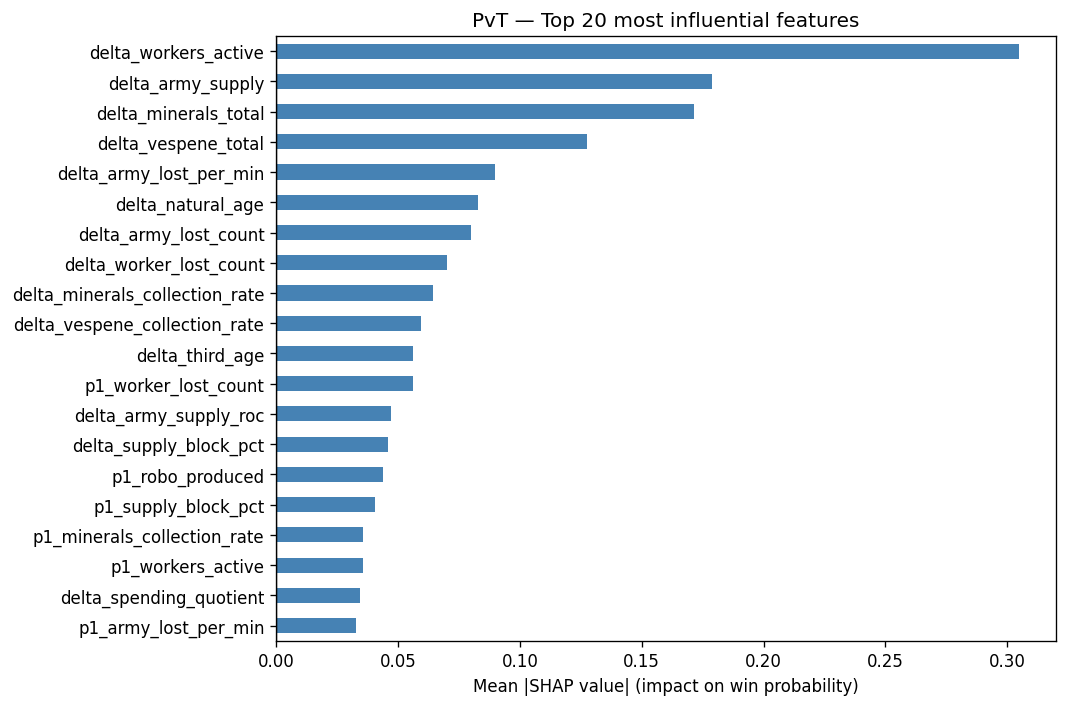

delta_workers_active              0.304759
delta_army_supply                 0.178980
delta_minerals_total              0.171619
delta_vespene_total               0.127581
delta_army_lost_per_min           0.089799
delta_natural_age                 0.082781
delta_army_lost_count             0.079988
delta_worker_lost_count           0.070116
delta_minerals_collection_rate    0.064450
delta_vespene_collection_rate     0.059385
delta_third_age                   0.056013
p1_worker_lost_count              0.055950
delta_army_supply_roc             0.047245
delta_supply_block_pct            0.045959
p1_robo_produced                  0.043831
p1_supply_block_pct               0.040373
p1_minerals_collection_rate       0.035703
p1_workers_active                 0.035628
delta_spending_quotient           0.034365
p1_army_lost_per_min              0.032596


In [6]:
# Top 20 features for PvT
top = top_features(sv_pvt, X_pvt, n=20)

fig, ax = plt.subplots(figsize=(9, 6))
top.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Mean |SHAP value| (impact on win probability)')
ax.set_title('PvT — Top 20 most influential features')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(top.to_string())

---
## Step 4 - Beeswarm plot

Shows both the **magnitude** and **direction** of each feature's impact.
- Red = high feature value, Blue = low feature value
- Right of centre = pushes win probability UP for P1
- Left of centre = pushes win probability DOWN for P1

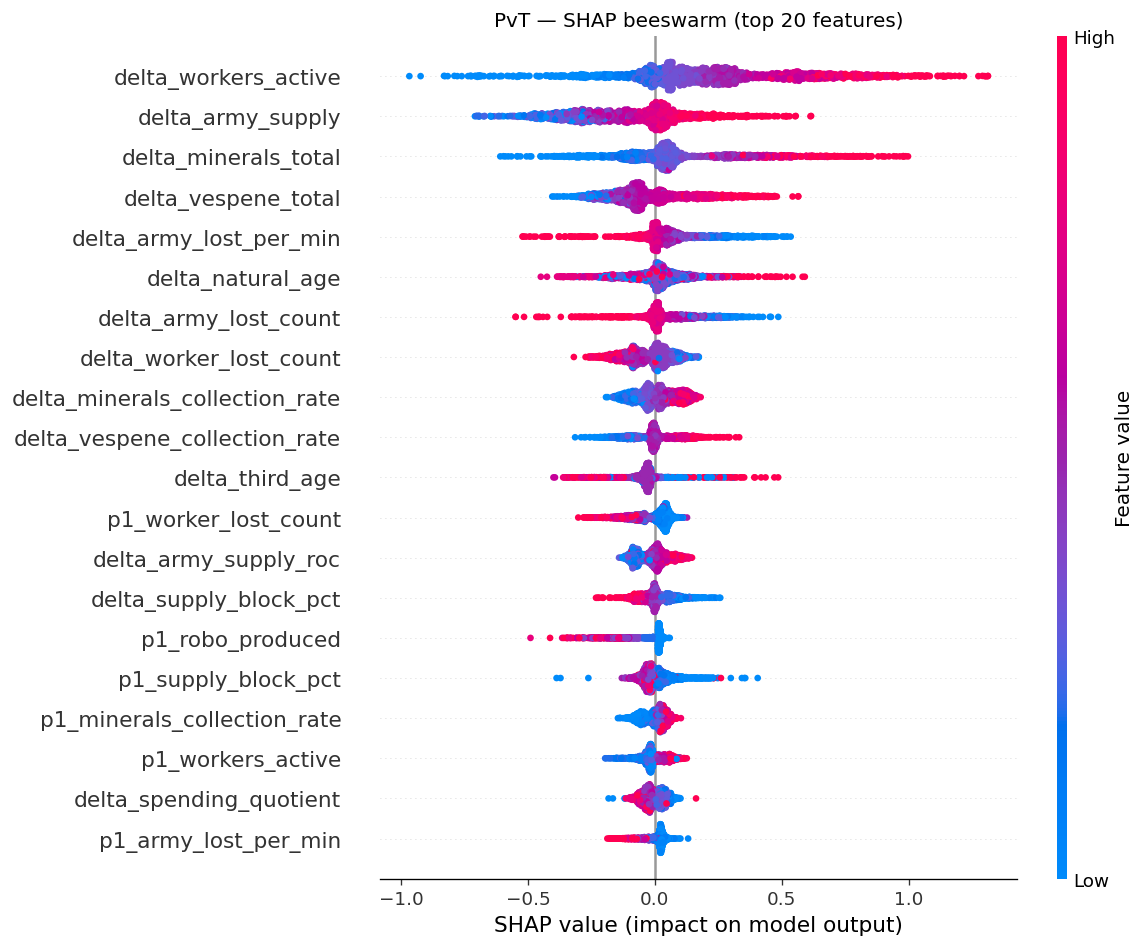

In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_pvt, X_pvt, max_display=20,
                  show=False, plot_size=None)
plt.title('PvT — SHAP beeswarm (top 20 features)')
plt.tight_layout()
plt.show()

---
## Step 5 - All matchups: feature importance comparison

In [8]:
all_shap = {}
all_X    = {}
all_df   = {}

# PvT already computed
all_shap['PvT'] = sv_pvt
all_X['PvT']    = X_pvt
all_df['PvT']   = df_pvt

for m in ['TvZ', 'TvT', 'PvZ', 'PvP']:
    print(f'Computing SHAP for {m}...')
    sv, X, df_m = compute_shap(m)
    all_shap[m] = sv
    all_X[m]    = X
    all_df[m]   = df_m

print('Done.')

Computing SHAP for TvZ...
Computing SHAP for TvT...
Computing SHAP for PvZ...
Computing SHAP for PvP...
Done.


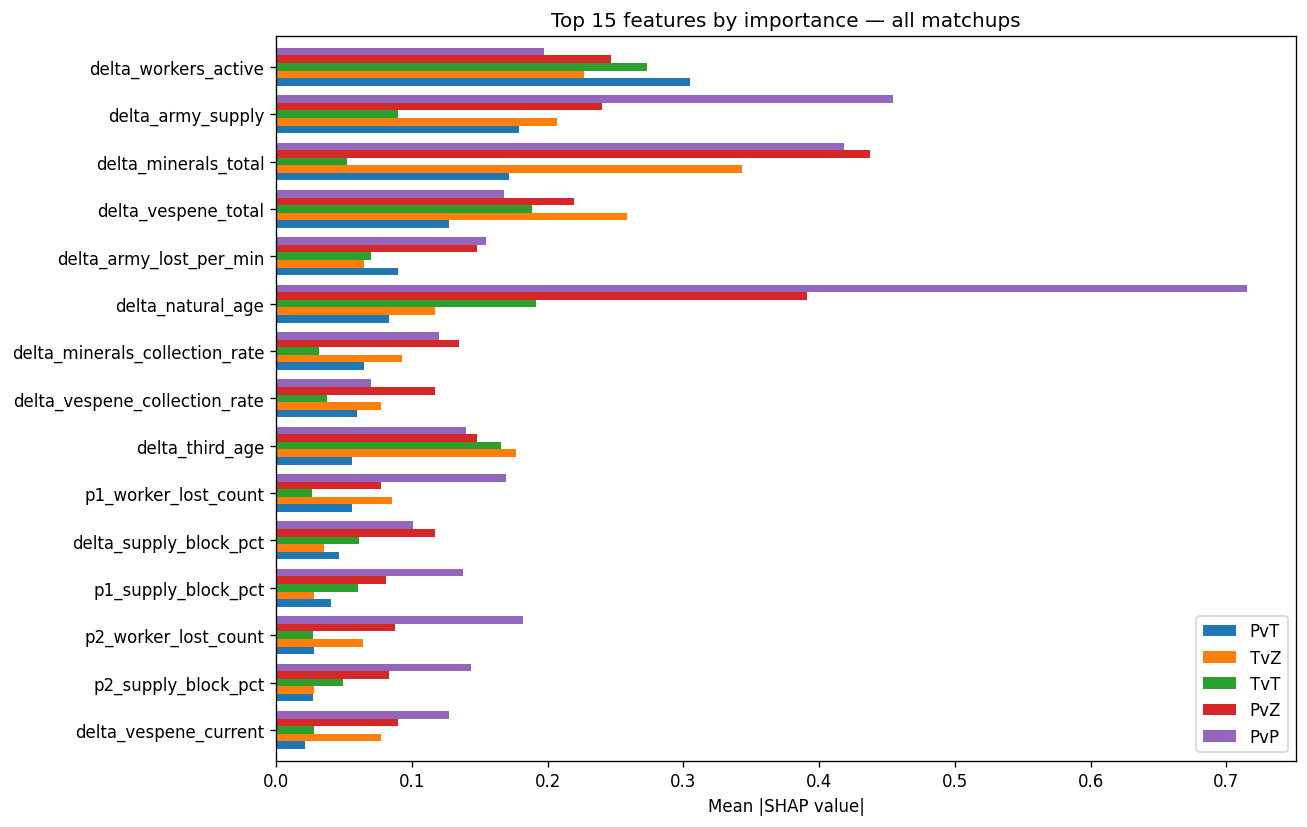

In [9]:
# Compare top-10 features across all matchups
importance_df = pd.DataFrame({
    m: pd.Series(np.abs(all_shap[m]).mean(axis=0), index=all_X[m].columns)
    for m in MATCHUPS
})

# Rank by average importance across matchups, show top 15
top15 = importance_df.mean(axis=1).sort_values(ascending=False).head(15).index
plot_df = importance_df.loc[top15].sort_values('PvT')

fig, ax = plt.subplots(figsize=(11, 7))
plot_df.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 15 features by importance — all matchups')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Step 6 - Dependence plots: impact of specific features

A dependence plot shows: for a given feature value, what is the SHAP impact?
This directly answers "what is the win % impact of X?"

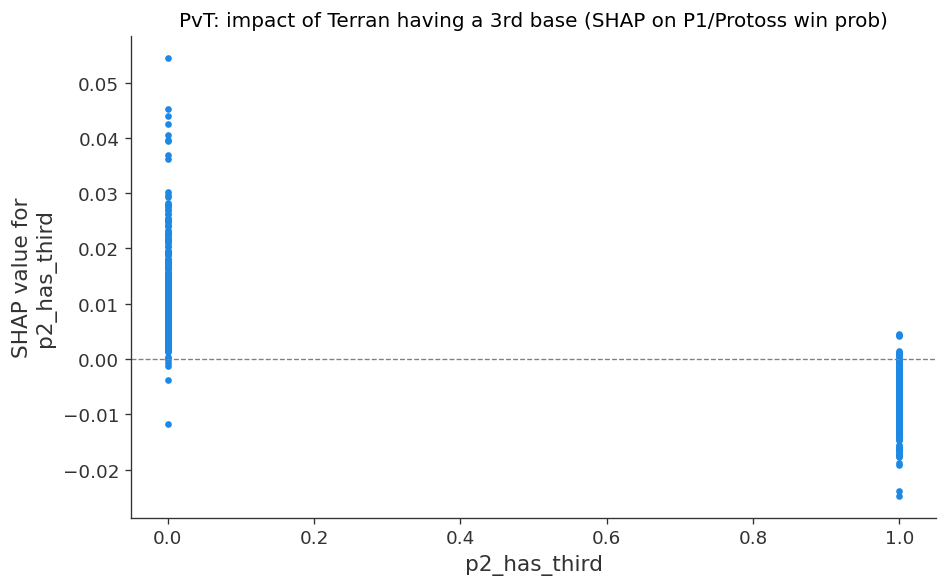

In [10]:
def dependence_plot(matchup, feature, interaction=None, title=None):
    """Plot SHAP dependence for a single feature."""
    sv = all_shap[matchup]
    X  = all_X[matchup]
    if feature not in X.columns:
        print(f'{feature} not found in {matchup} features')
        return
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(
        feature, sv, X,
        interaction_index=interaction,
        ax=ax, show=False,
    )
    ax.set_title(title or f'{matchup}: impact of {feature}')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    plt.tight_layout()
    plt.show()

# --- 3rd base timing in PvT ---
# p2 = Terran in PvT (after normalization)
# p2_has_third = 1 if Terran has a 3rd base, 0 if not
dependence_plot('PvT', 'p2_has_third',
                title='PvT: impact of Terran having a 3rd base (SHAP on P1/Protoss win prob)')

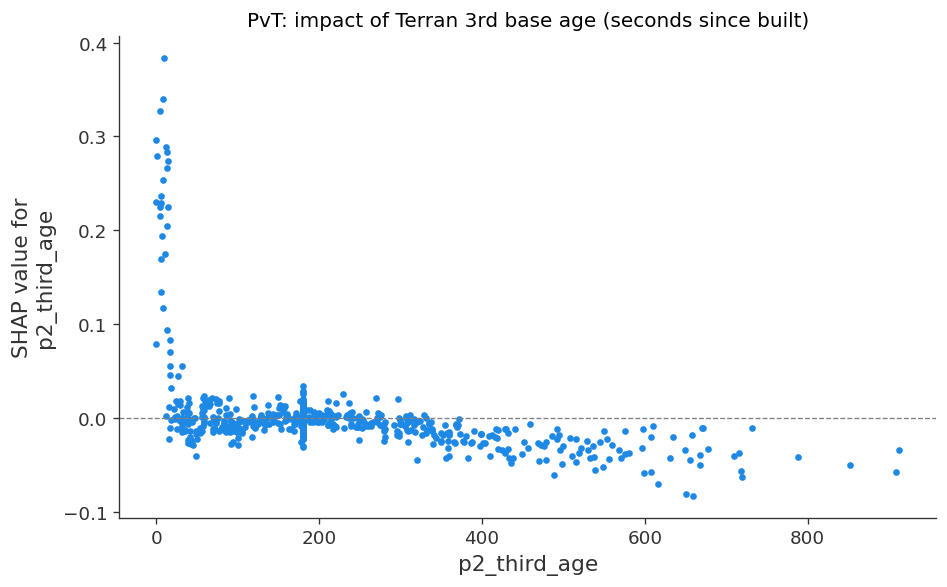

In [11]:
# --- Terran 3rd base age (how long ago it was built) ---
dependence_plot('PvT', 'p2_third_age',
                title='PvT: impact of Terran 3rd base age (seconds since built)')

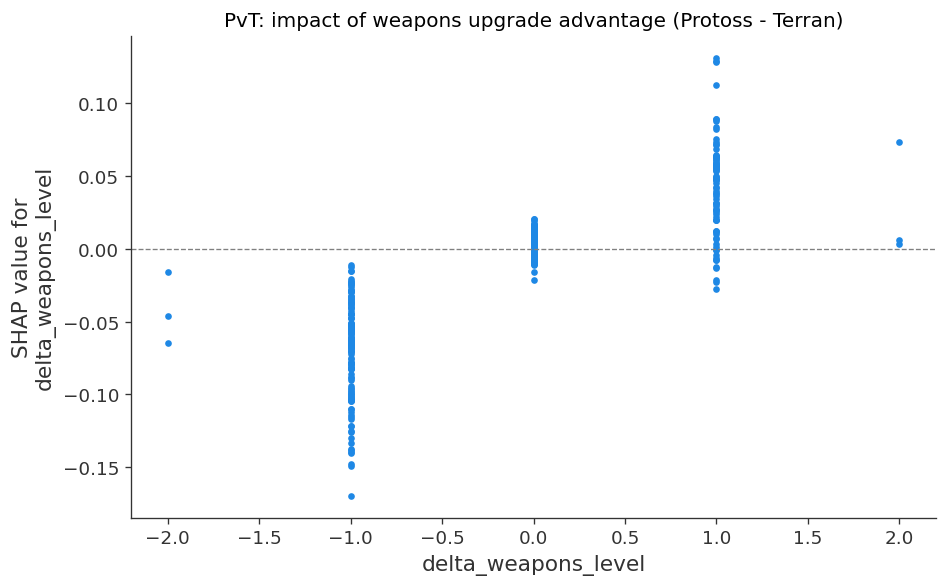

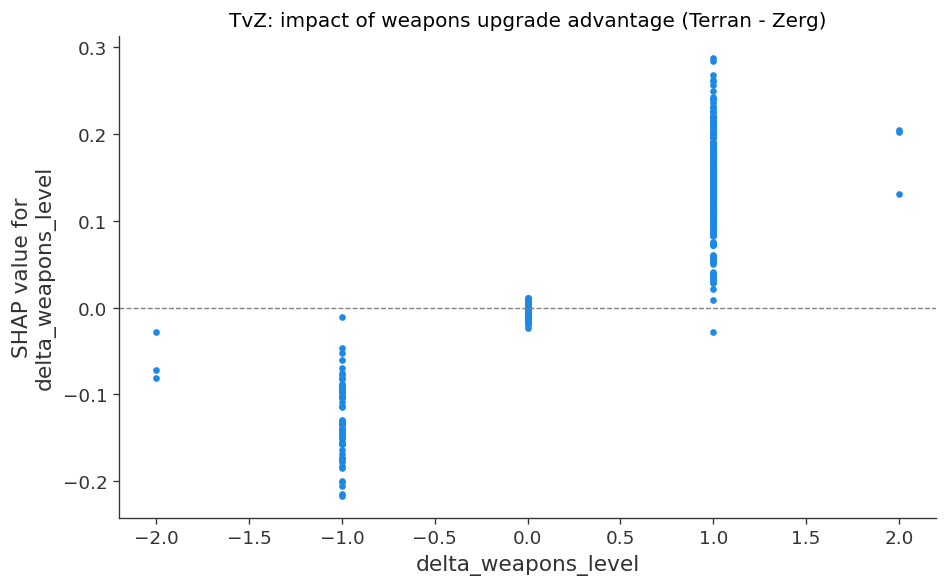

In [12]:
# --- Upgrade levels ---
dependence_plot('PvT', 'delta_weapons_level',
                title='PvT: impact of weapons upgrade advantage (Protoss - Terran)')
dependence_plot('TvZ', 'delta_weapons_level',
                title='TvZ: impact of weapons upgrade advantage (Terran - Zerg)')

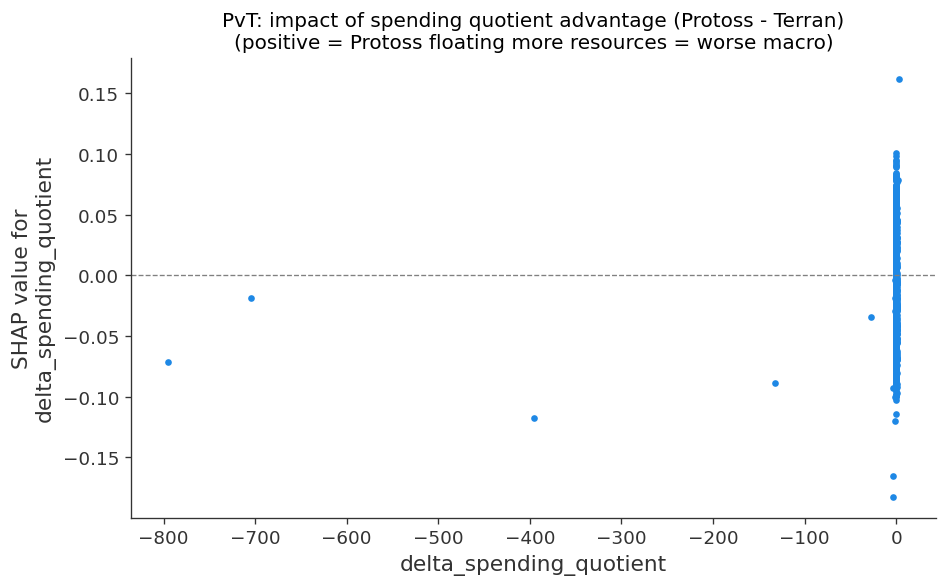

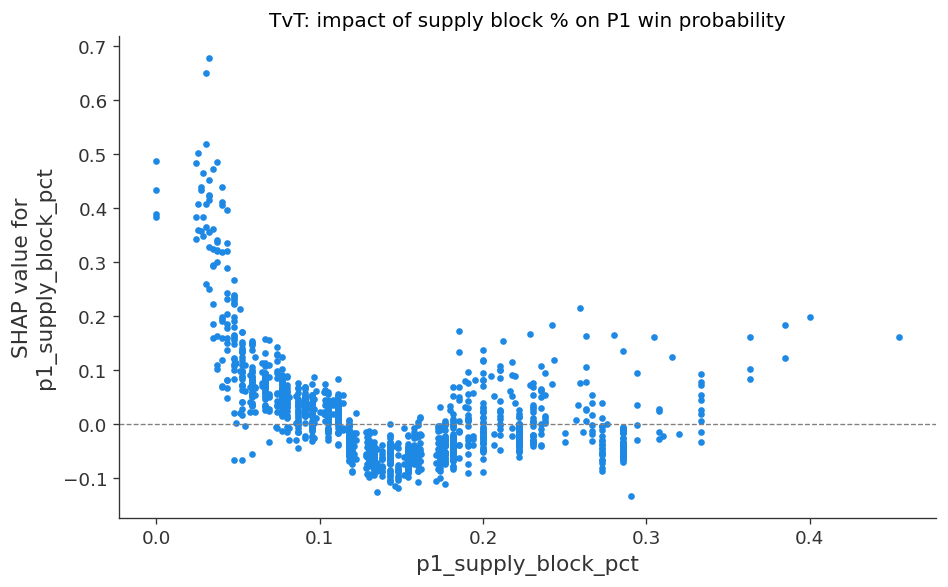

In [13]:
# --- Spending efficiency ---
dependence_plot('PvT', 'delta_spending_quotient',
                title='PvT: impact of spending quotient advantage (Protoss - Terran)\n(positive = Protoss floating more resources = worse macro)')
dependence_plot('TvT', 'p1_supply_block_pct',
                title='TvT: impact of supply block % on P1 win probability')

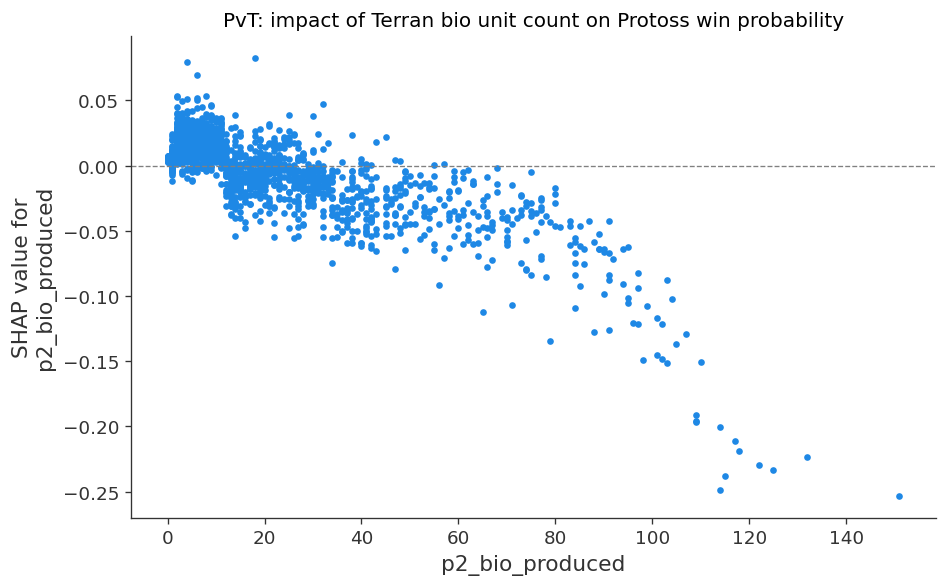

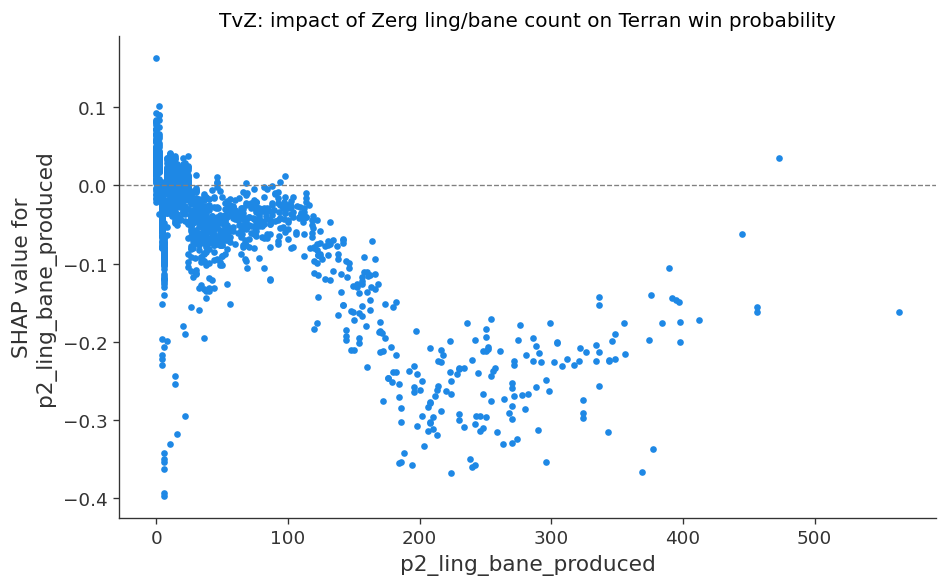

In [14]:
# --- Unit composition ---
dependence_plot('PvT', 'p2_bio_produced',
                title='PvT: impact of Terran bio unit count on Protoss win probability')
dependence_plot('TvZ', 'p2_ling_bane_produced',
                title='TvZ: impact of Zerg ling/bane count on Terran win probability')

---
## Step 7 - Feature importance by game minute

Which features matter most **early** vs **late** in the game?

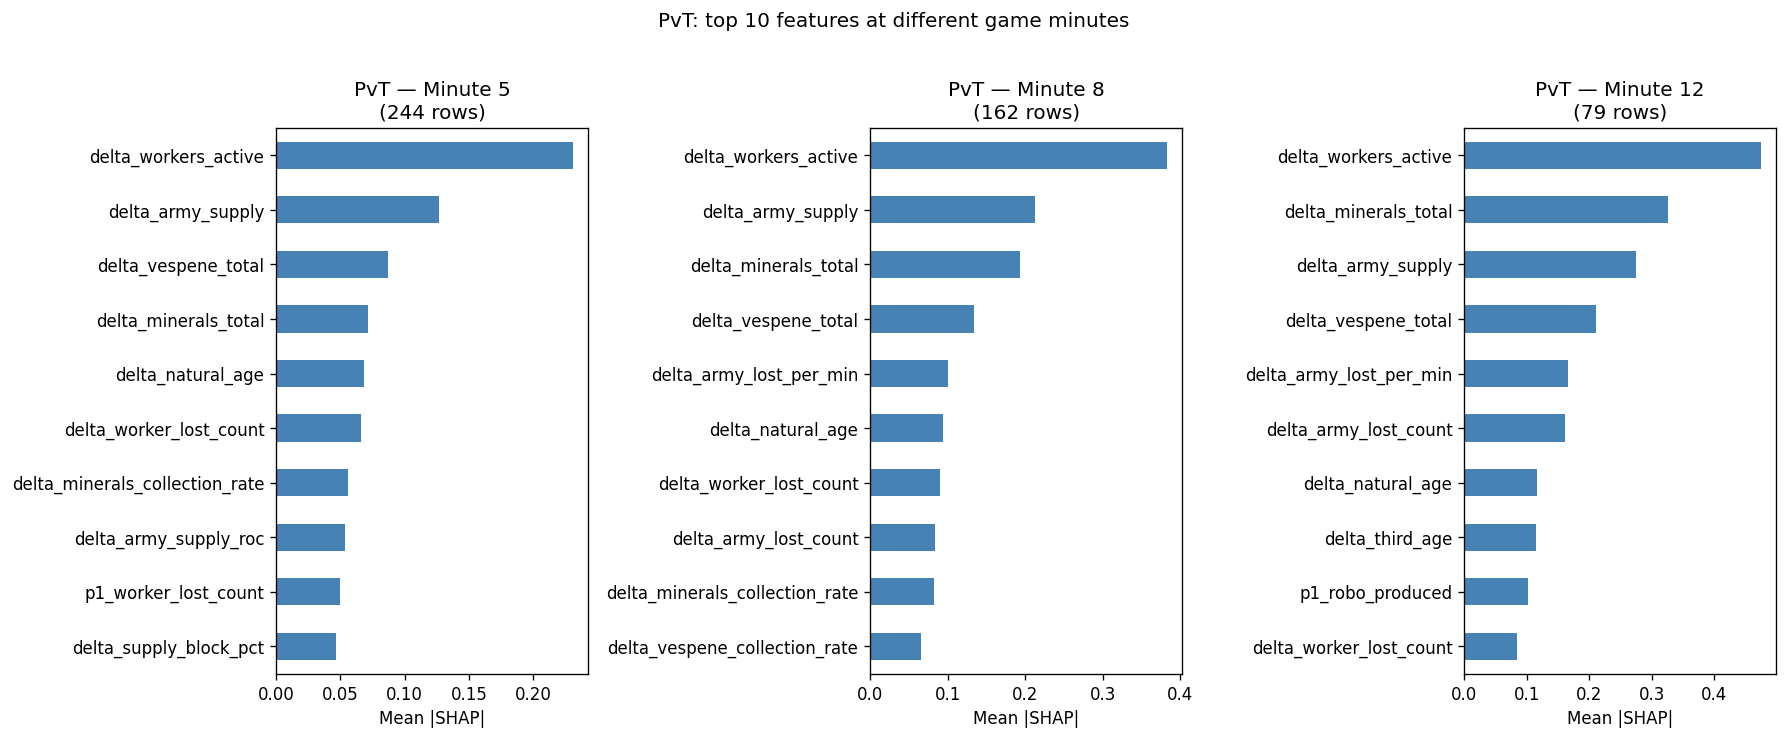

In [15]:
def importance_by_minute(matchup, minutes=[5, 8, 12], top_n=10):
    """Show top features at specific game minutes."""
    df_m = all_df[matchup]
    X_m  = all_X[matchup]
    sv_m = all_shap[matchup]

    fig, axes = plt.subplots(1, len(minutes), figsize=(5 * len(minutes), 6), sharey=False)
    if len(minutes) == 1:
        axes = [axes]

    for ax, minute in zip(axes, minutes):
        mask = (df_m['game_minute'] == float(minute)).values
        if mask.sum() < 5:
            ax.set_title(f'Min {minute} (too few rows)')
            continue
        sv_min = sv_m[mask]
        X_min  = X_m.iloc[mask] if hasattr(X_m, 'iloc') else X_m[mask]
        mean_abs = pd.Series(np.abs(sv_min).mean(axis=0), index=X_m.columns)
        top = mean_abs.sort_values(ascending=False).head(top_n).sort_values()
        top.plot.barh(ax=ax, color='steelblue')
        ax.set_title(f'{matchup} — Minute {minute}\n({mask.sum()} rows)')
        ax.set_xlabel('Mean |SHAP|')

    plt.suptitle(f'{matchup}: top {top_n} features at different game minutes', y=1.02)
    plt.tight_layout()
    plt.show()

importance_by_minute('PvT', minutes=[5, 8, 12])

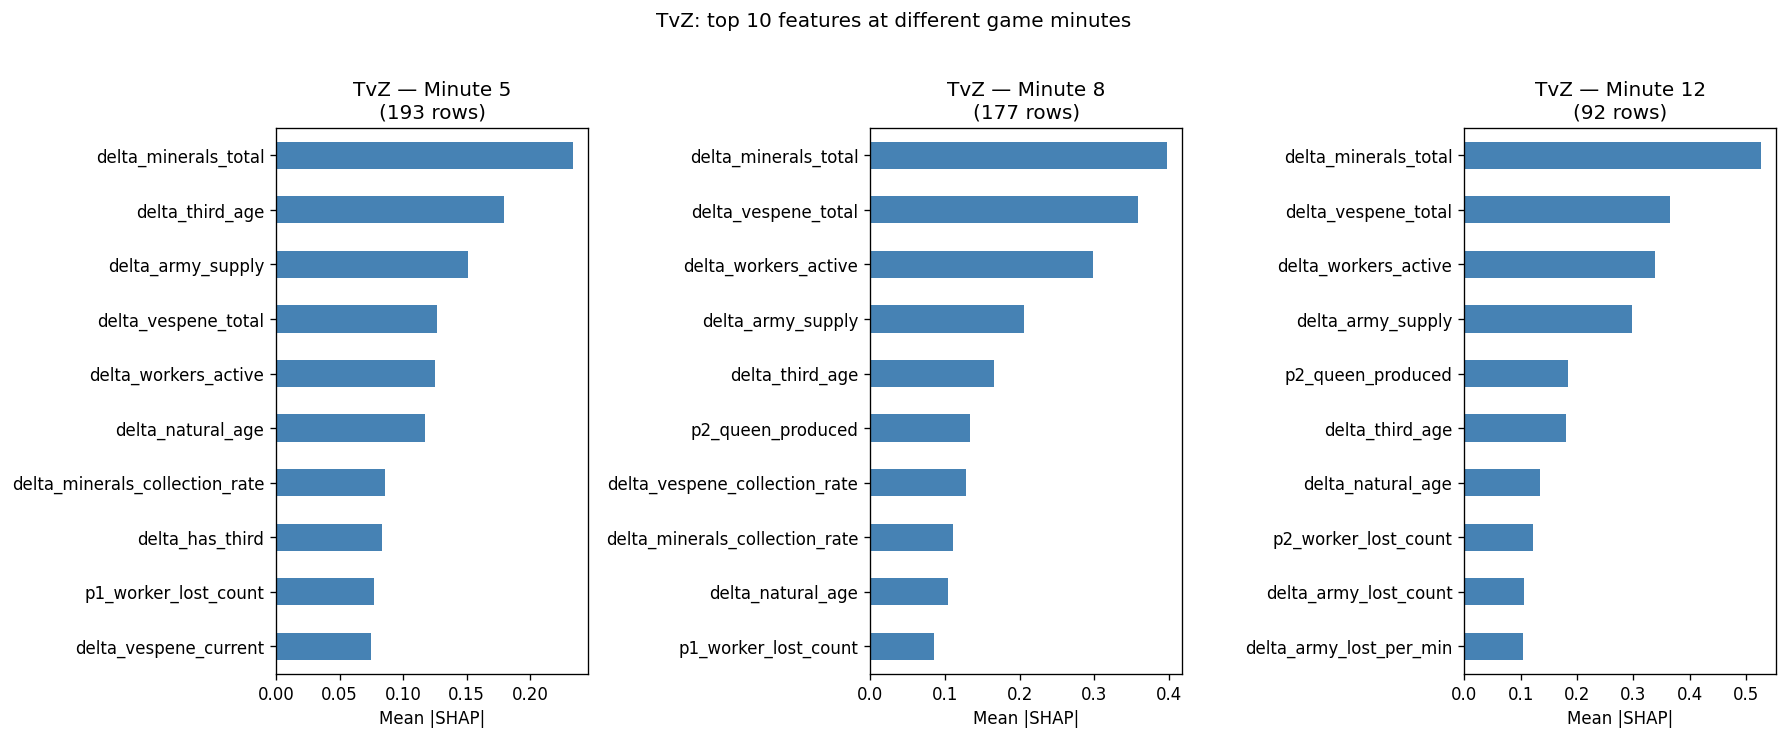

In [16]:
importance_by_minute('TvZ', minutes=[5, 8, 12])

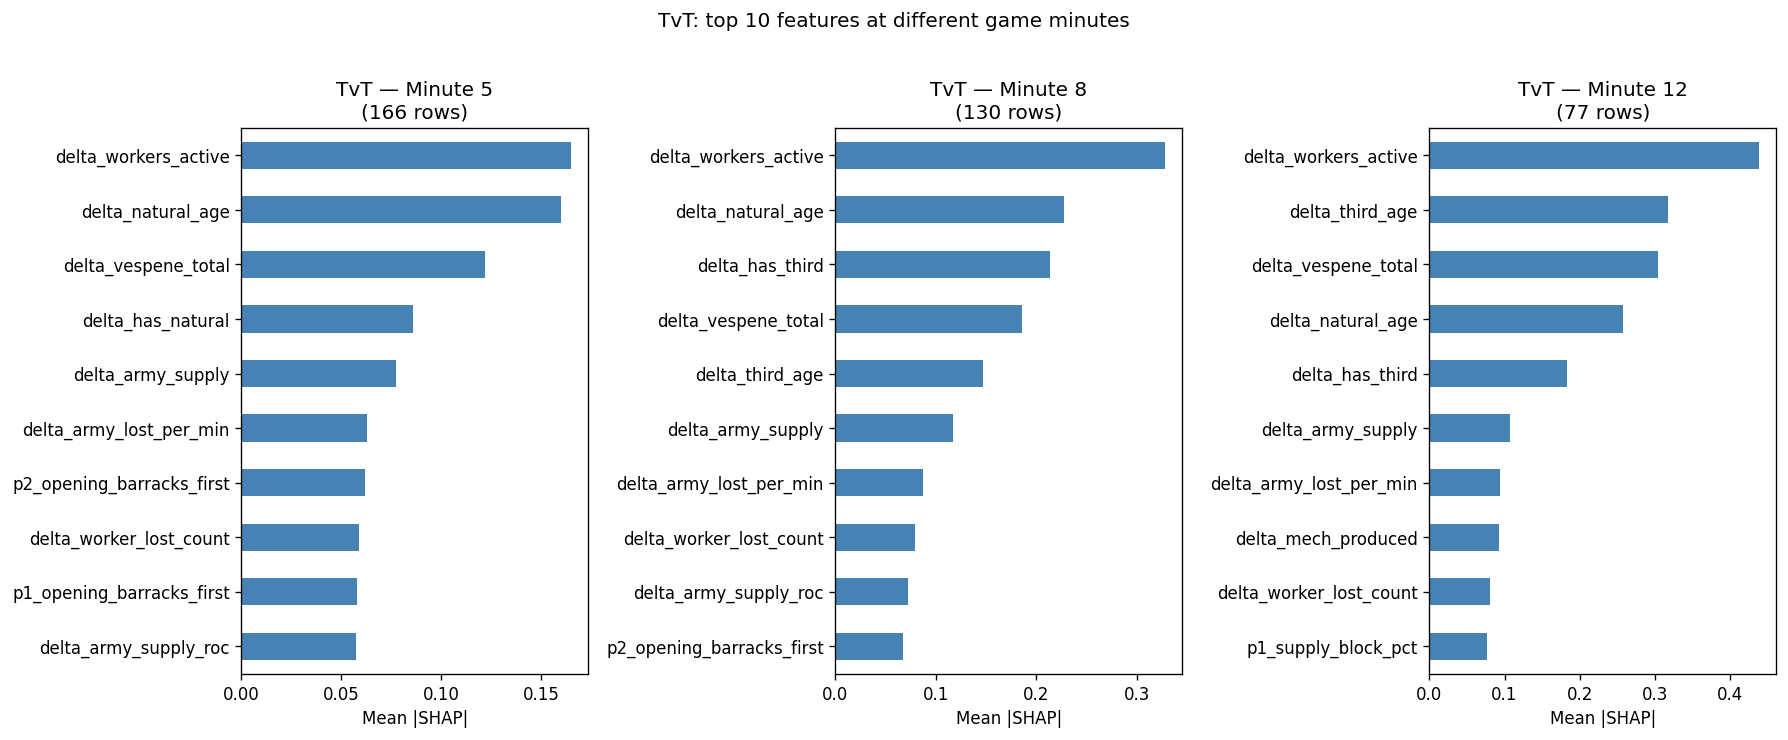

In [17]:
importance_by_minute('TvT', minutes=[5, 8, 12])

---
## Step 8 - Single game explanation

For one specific game, show exactly which features pushed the win probability
up or down — the waterfall chart.

PvT — game 0 at minute 8
Predicted win prob for P1: 28.3%
Actual winner: P2


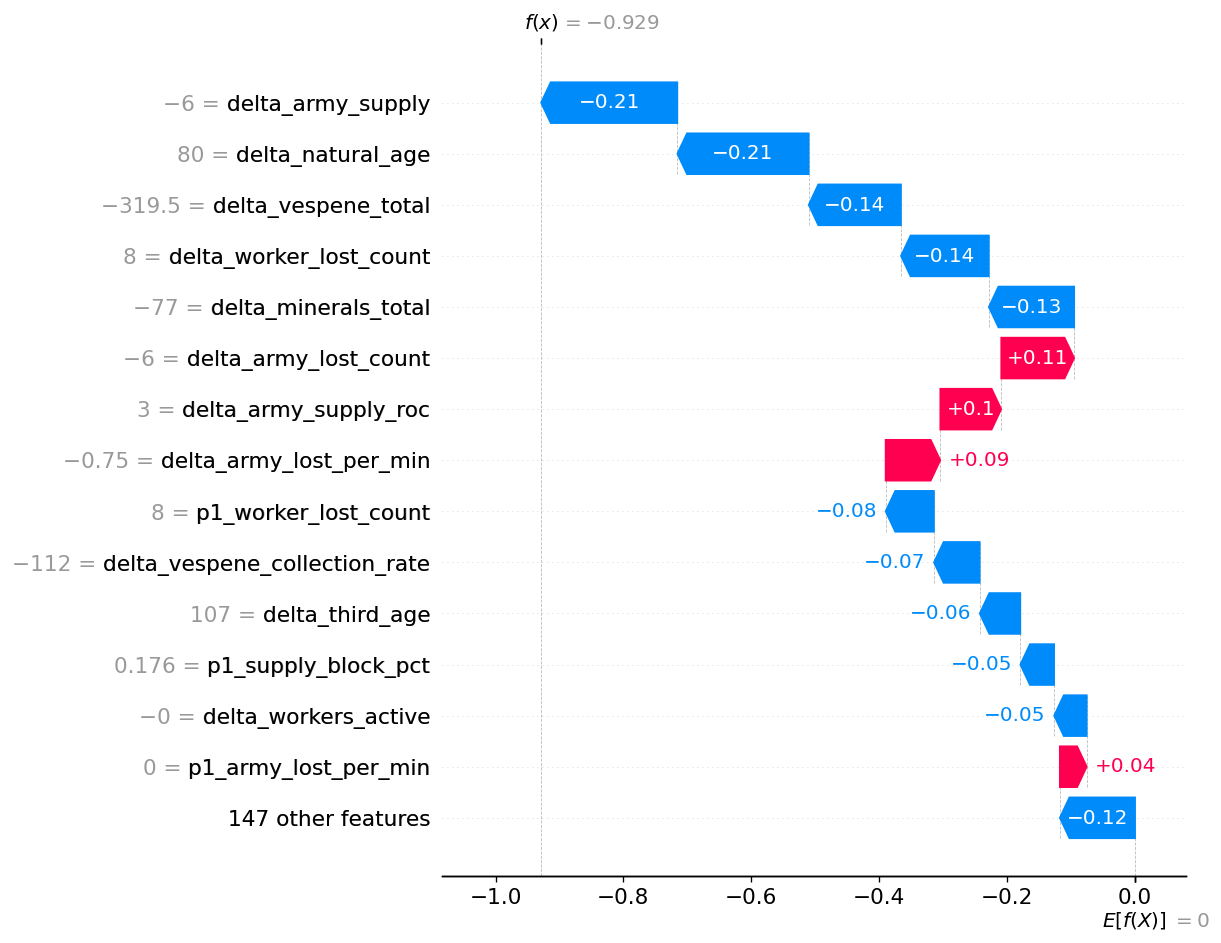

In [18]:
def explain_game_at_minute(matchup, game_idx=0, minute=8):
    """
    Show a waterfall SHAP explanation for one game at a specific minute.
    game_idx: index into the test set games (0 = first test game)
    """
    df_m = all_df[matchup]
    X_m  = all_X[matchup]
    sv_m = all_shap[matchup]

    # Find rows for the chosen minute
    mask = (df_m['game_minute'] == float(minute)).values
    rows_at_min = np.where(mask)[0]

    if game_idx >= len(rows_at_min):
        print(f'Only {len(rows_at_min)} games at minute {minute}')
        return

    row_idx = rows_at_min[game_idx]
    explainer = shap.TreeExplainer(models[matchup])
    exp = explainer(X_m.iloc[[row_idx]])

    print(f'{matchup} — game {game_idx} at minute {minute}')
    print(f'Predicted win prob for P1: {models[matchup].predict_proba(X_m.iloc[[row_idx]])[0, 1]:.1%}')
    print(f'Actual winner: P{int(df_m.iloc[row_idx]["winner"] if "winner" in df_m.columns else "?")}')

    shap.plots.waterfall(exp[0], max_display=15, show=True)

explain_game_at_minute('PvT', game_idx=0, minute=8)

PvT — game 1 at minute 8
Predicted win prob for P1: 67.6%
Actual winner: P2


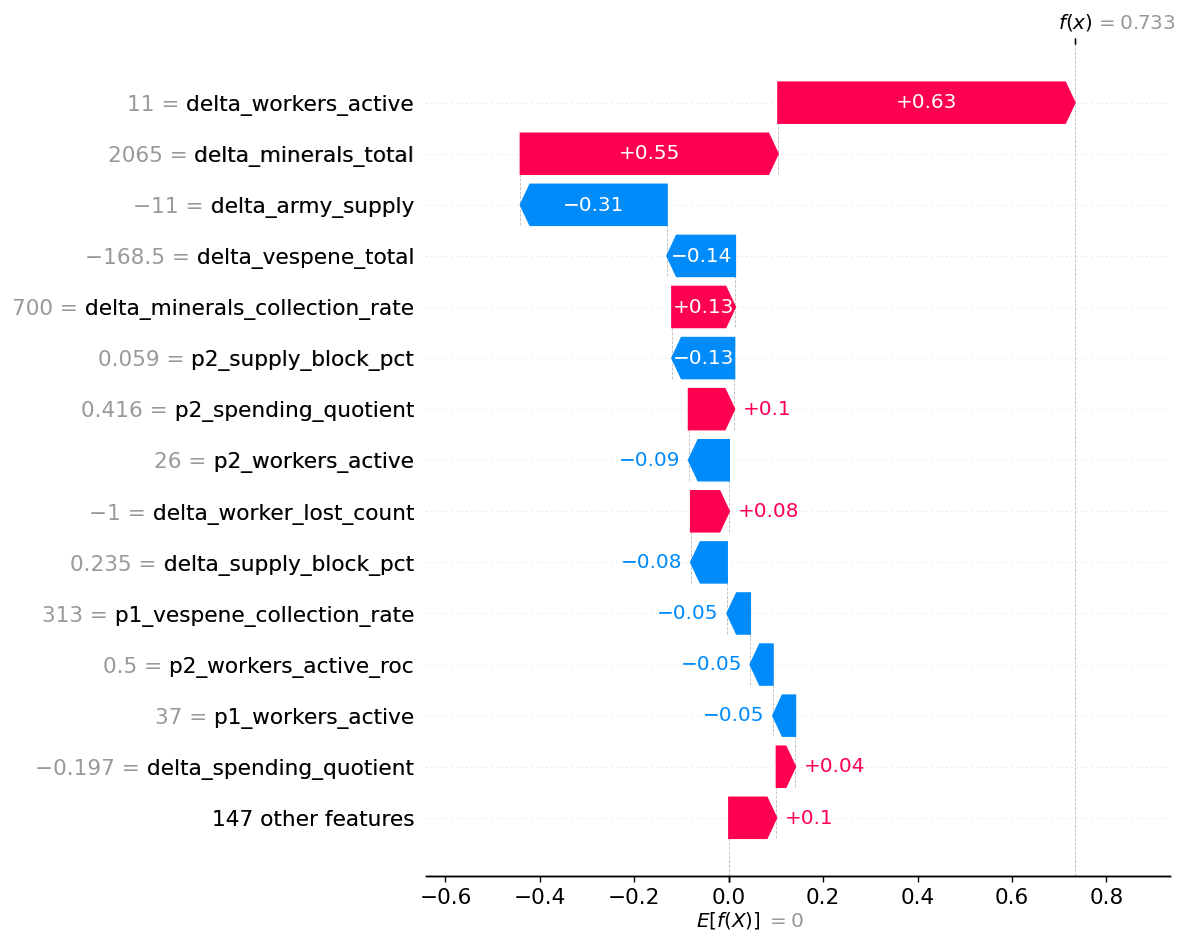

In [19]:
# Try a different game or minute
explain_game_at_minute('PvT', game_idx=1, minute=8)

---
## Step 9 - 3rd base timing vs win rate

For each game, compute **when Terran took their 3rd base** and plot the actual
win rate bucketed by timing. This is a direct, easy-to-read answer to
"does early 3rd base timing predict Terran winning?"

PvT — Terran 3rd base analysis
  Games where Terran took a 3rd : 1041
  Games where Terran had no 3rd : 1554
  Terran win rate with NO 3rd    : 50.7%


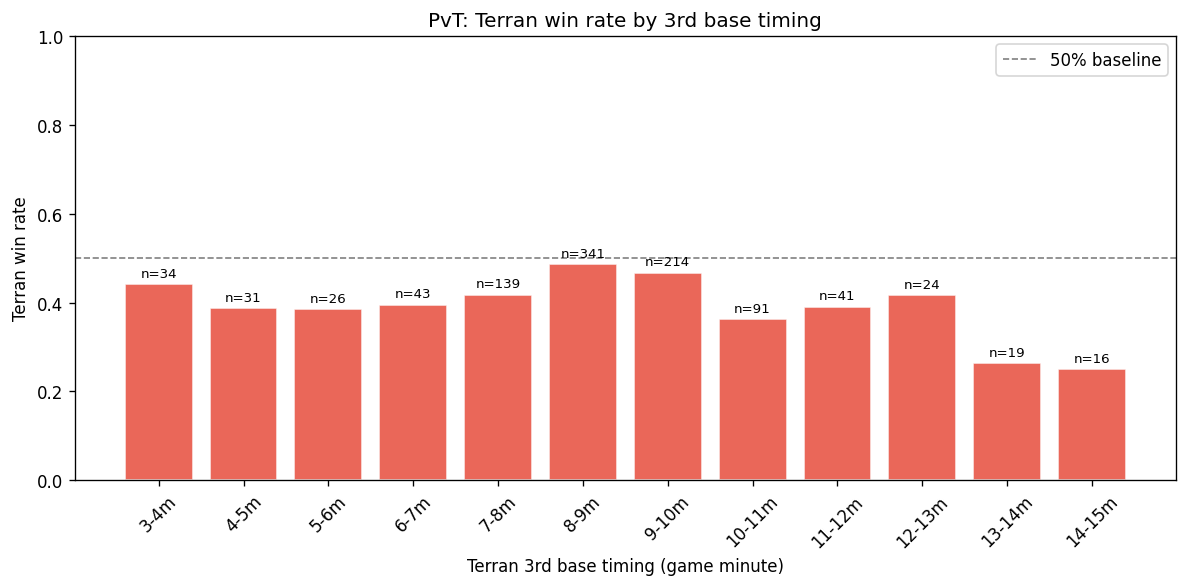

In [20]:
def third_base_timing_winrate(matchup, race_label, p_col='p2'):
    """
    Plot win rate by 3rd base timing bucket for a specific player/race in a matchup.
    Reconstructs timing from: third_sec = checkpoint_sec - third_age
    """
    df_m = df[df['matchup'] == matchup].copy()

    has_col  = f'{p_col}_has_third'
    age_col  = f'{p_col}_third_age'

    if has_col not in df_m.columns:
        print(f'{has_col} not found in dataframe')
        return

    # Reconstruct absolute 3rd base timing from the first checkpoint where it appears
    df_m['third_sec_reconstructed'] = np.where(
        df_m[has_col] == 1,
        df_m['checkpoint_sec'] - df_m[age_col],
        np.nan
    )

    # One row per game: earliest checkpoint where 3rd appears
    games_with_third = (
        df_m[df_m[has_col] == 1]
        .sort_values('checkpoint_sec')
        .groupby('replay_file')
        .first()
        .reset_index()
    )
    games_no_third = (
        df_m.groupby('replay_file')
        .filter(lambda g: (g[has_col] == 0).all())
        .groupby('replay_file')
        .first()
        .reset_index()
    )

    print(f"{matchup} — {race_label} 3rd base analysis")
    print(f"  Games where {race_label} took a 3rd : {len(games_with_third)}")
    print(f"  Games where {race_label} had no 3rd : {len(games_no_third)}")

    if len(games_no_third) > 0:
        wr = games_no_third['winner'].apply(
            lambda w: 1 if (p_col == 'p1' and w == 1) or (p_col == 'p2' and w == 2) else 0
        ).mean()
        print(f"  {race_label} win rate with NO 3rd    : {wr:.1%}")

    if len(games_with_third) < 10:
        print("Too few games with a 3rd to plot.")
        return

    games_with_third['third_min'] = games_with_third['third_sec_reconstructed'] / 60
    games_with_third['race_wins'] = games_with_third['winner'].apply(
        lambda w: 1 if (p_col == 'p1' and w == 1) or (p_col == 'p2' and w == 2) else 0
    )

    bins   = np.arange(3, 16, 1)
    labels = [f'{int(b)}-{int(b)+1}m' for b in bins[:-1]]
    games_with_third['timing_bucket'] = pd.cut(
        games_with_third['third_min'], bins=bins, labels=labels
    )

    bucket_stats = games_with_third.groupby('timing_bucket', observed=True).agg(
        win_rate=('race_wins', 'mean'),
        count=('race_wins', 'count')
    ).reset_index()
    bucket_stats = bucket_stats[bucket_stats['count'] >= 5]  # hide tiny buckets

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(
        bucket_stats['timing_bucket'].astype(str),
        bucket_stats['win_rate'],
        color=['#2ecc71' if w >= 0.5 else '#e74c3c' for w in bucket_stats['win_rate']],
        alpha=0.85, edgecolor='white'
    )
    for bar, (_, row) in zip(bars, bucket_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='50% baseline')
    ax.set_ylim(0, 1)
    ax.set_xlabel(f'{race_label} 3rd base timing (game minute)')
    ax.set_ylabel(f'{race_label} win rate')
    ax.set_title(f'{matchup}: {race_label} win rate by 3rd base timing')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

third_base_timing_winrate('PvT', race_label='Terran', p_col='p2')

PvT — Protoss 3rd base analysis
  Games where Protoss took a 3rd : 1569
  Games where Protoss had no 3rd : 1026
  Protoss win rate with NO 3rd    : 45.8%


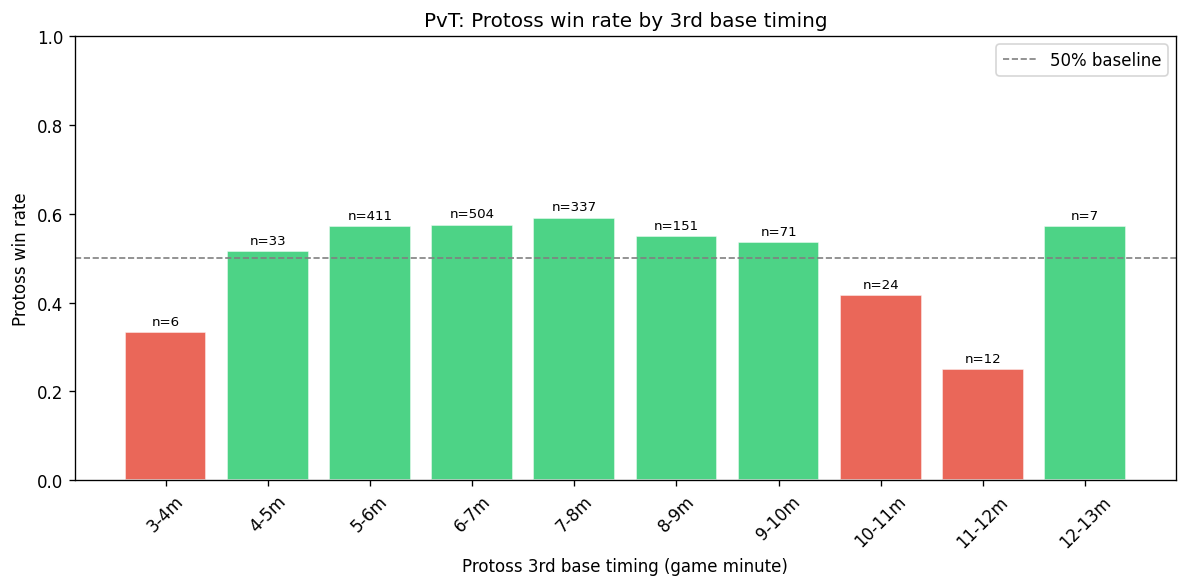

TvZ — Terran 3rd base analysis
  Games where Terran took a 3rd : 1525
  Games where Terran had no 3rd : 344
  Terran win rate with NO 3rd    : 34.6%


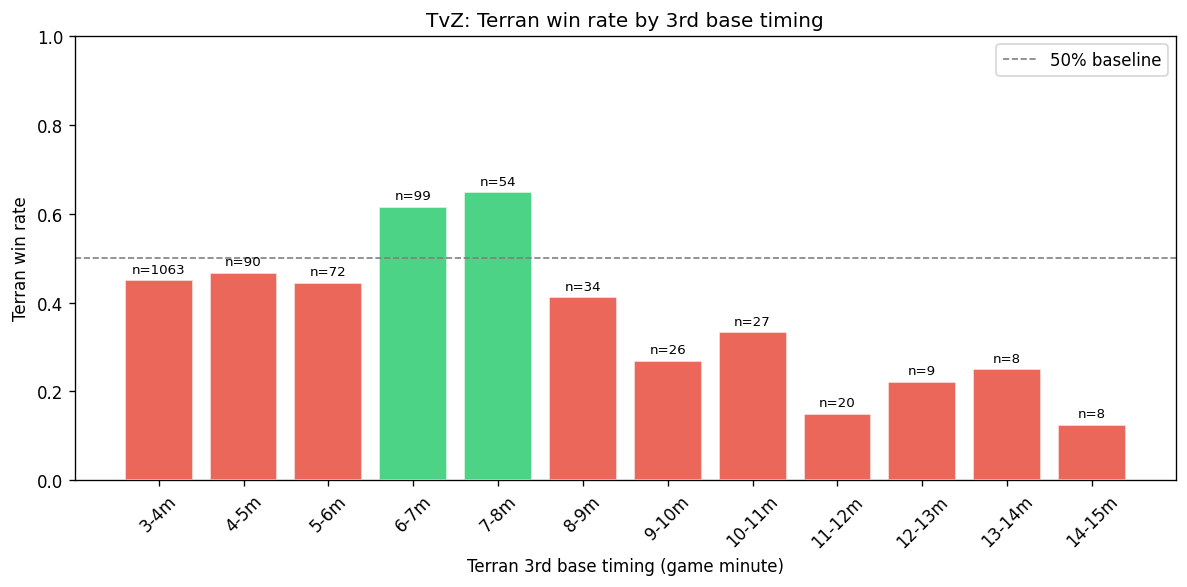

TvZ — Zerg 3rd base analysis
  Games where Zerg took a 3rd : 1643
  Games where Zerg had no 3rd : 226
  Zerg win rate with NO 3rd    : 61.9%


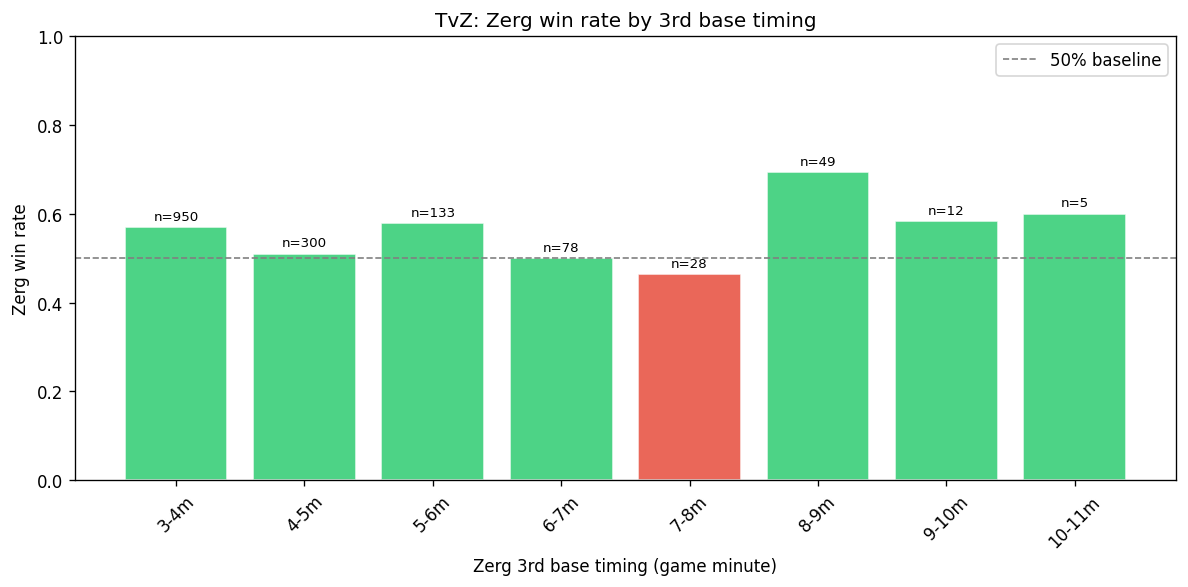

In [21]:
# You can call this for any matchup/race combination:
third_base_timing_winrate('PvT', race_label='Protoss', p_col='p1')
third_base_timing_winrate('TvZ', race_label='Terran',  p_col='p1')
third_base_timing_winrate('TvZ', race_label='Zerg',    p_col='p2')

PvZ — Protoss 3rd base analysis
  Games where Protoss took a 3rd : 624
  Games where Protoss had no 3rd : 125
  Protoss win rate with NO 3rd    : 47.2%


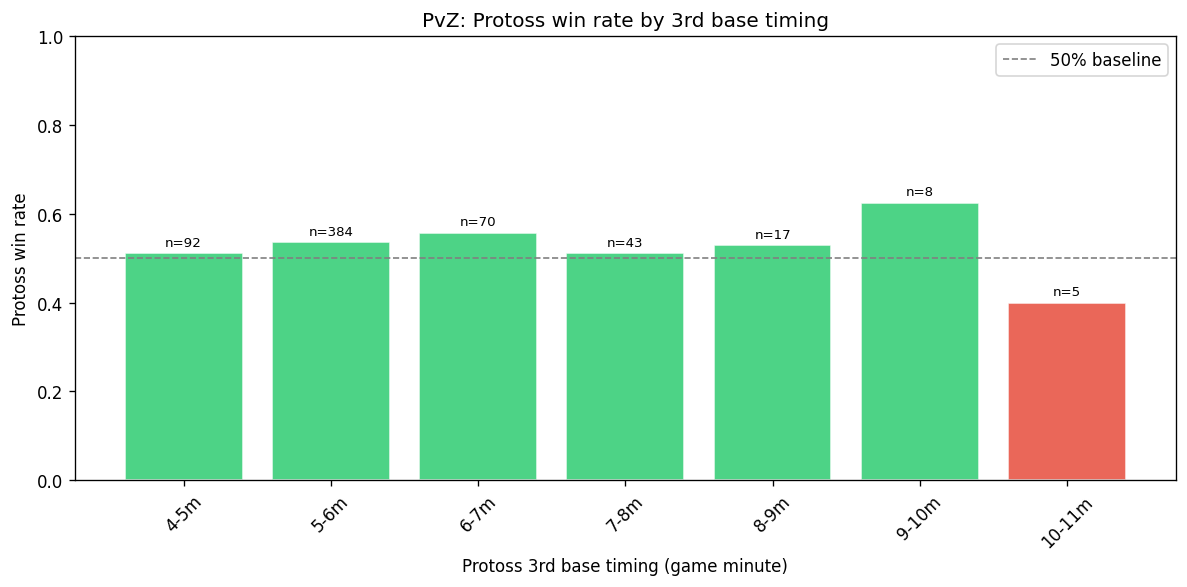

In [22]:
third_base_timing_winrate('PvZ', race_label='Protoss', p_col='p1')


PvZ — Protoss 3rd base analysis
  Games where Protoss took a 3rd : 624
  Games where Protoss had no 3rd : 125
  Protoss win rate with NO 3rd    : 47.2%


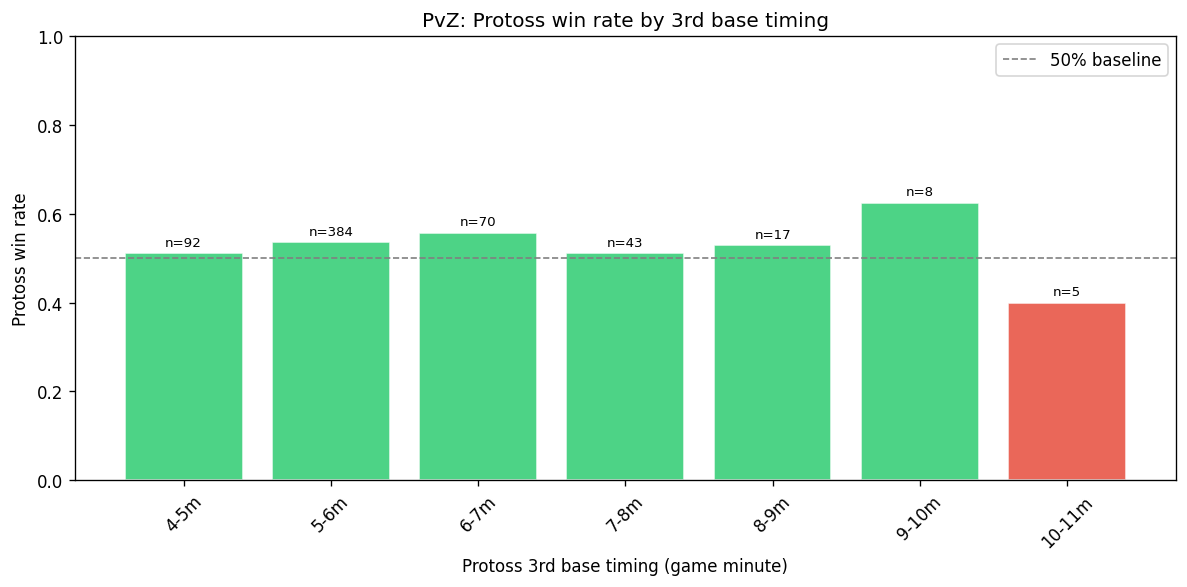

PvZ — Zerg 3rd base analysis
  Games where Zerg took a 3rd : 676
  Games where Zerg had no 3rd : 73
  Zerg win rate with NO 3rd    : 57.5%


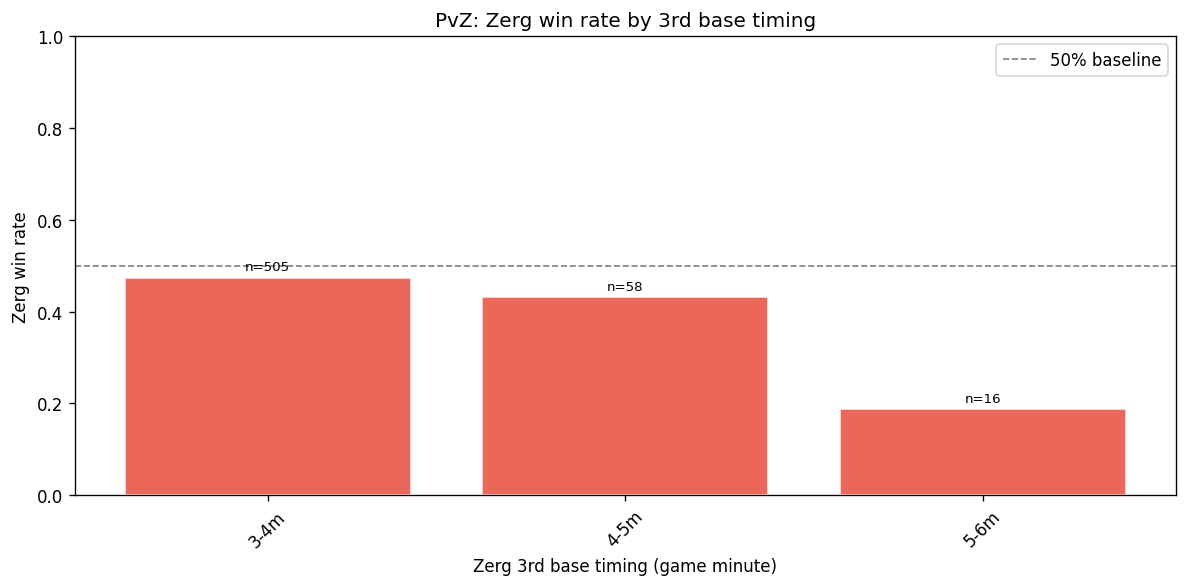

In [23]:
third_base_timing_winrate('PvZ', race_label='Protoss', p_col='p1')
third_base_timing_winrate('PvZ', race_label='Zerg',    p_col='p2')


In [24]:
# PvZ — Zerg win rate when Zerg has no natural
df_pvz = df[df['matchup'] == 'PvZ'].copy()

# Per-game: did Zerg ever have a natural?
game_natural = df_pvz.groupby('replay_file').agg(
    ever_had_natural=('p2_has_natural', 'max'),
    winner=('winner', 'first')
).reset_index()

no_natural = game_natural[game_natural['ever_had_natural'] == 0]
zerg_wins  = (no_natural['winner'] == 2).sum()
total      = len(no_natural)

print(f"PvZ — Zerg games with NO natural: {total}")
print(f"Zerg wins: {zerg_wins} / {total} = {zerg_wins/total*100:.1f}%" if total > 0 else "No games found")


PvZ — Zerg games with NO natural: 31
Zerg wins: 19 / 31 = 61.3%


In [25]:
# PvP — win rate when a player has no natural
df_pvp = df[df['matchup'] == 'PvP'].copy()

# Per-game: did each player ever have a natural?
game_natural = df_pvp.groupby('replay_file').agg(
    p1_ever_natural=('p1_has_natural', 'max'),
    p2_ever_natural=('p2_has_natural', 'max'),
    winner=('winner', 'first')
).reset_index()

# P1 has no natural
p1_no_nat = game_natural[game_natural['p1_ever_natural'] == 0]
p1_wins   = (p1_no_nat['winner'] == 1).sum()
print(f"P1 (no natural): {p1_wins}/{len(p1_no_nat)} wins = {p1_wins/len(p1_no_nat)*100:.1f}%" if len(p1_no_nat) > 0 else "P1: no games found")

# P2 has no natural
p2_no_nat = game_natural[game_natural['p2_ever_natural'] == 0]
p2_wins   = (p2_no_nat['winner'] == 2).sum()
print(f"P2 (no natural): {p2_wins}/{len(p2_no_nat)} wins = {p2_wins/len(p2_no_nat)*100:.1f}%" if len(p2_no_nat) > 0 else "P2: no games found")

# Either player has no natural
either_no_nat = game_natural[(game_natural['p1_ever_natural'] == 0) | (game_natural['p2_ever_natural'] == 0)]
no_nat_winner_wins = (
    ((either_no_nat['p1_ever_natural'] == 0) & (either_no_nat['winner'] == 1)) |
    ((either_no_nat['p2_ever_natural'] == 0) & (either_no_nat['winner'] == 2))
).sum()
print(f"\nPlayer with NO natural wins: {no_nat_winner_wins}/{len(either_no_nat)} = {no_nat_winner_wins/len(either_no_nat)*100:.1f}%")


P1 (no natural): 61/99 wins = 61.6%
P2 (no natural): 53/121 wins = 43.8%

Player with NO natural wins: 114/167 = 68.3%


In [26]:
# PvP — win rate when exactly one player has a natural and the other does not
df_pvp = df[df['matchup'] == 'PvP'].copy()

game_natural = df_pvp.groupby('replay_file').agg(
    p1_ever_natural=('p1_has_natural', 'max'),
    p2_ever_natural=('p2_has_natural', 'max'),
    winner=('winner', 'first')
).reset_index()

# Exactly one player took a natural
asymmetric = game_natural[game_natural['p1_ever_natural'] != game_natural['p2_ever_natural']].copy()

print(f"Games where exactly one player took a natural: {len(asymmetric)}")

# Did the player WITH the natural win?
natural_player_wins = (
    ((asymmetric['p1_ever_natural'] == 1) & (asymmetric['winner'] == 1)) |
    ((asymmetric['p2_ever_natural'] == 1) & (asymmetric['winner'] == 2))
).sum()

print(f"Player WITH natural wins:    {natural_player_wins}/{len(asymmetric)} = {natural_player_wins/len(asymmetric)*100:.1f}%")
print(f"Player WITHOUT natural wins: {len(asymmetric)-natural_player_wins}/{len(asymmetric)} = {(len(asymmetric)-natural_player_wins)/len(asymmetric)*100:.1f}%")


Games where exactly one player took a natural: 114
Player WITH natural wins:    53/114 = 46.5%
Player WITHOUT natural wins: 61/114 = 53.5%


---
## Step 10 - Opening build order win rates (PvP)

Detects each player's first non-supply building and computes win rates by opening type.
After re-parsing replays the new `p1_opening_*` / `p2_opening_*` columns will be available.


PvP — P1 (Protoss) opening win rates
─────────────────────────────────────────────
  gate_first          : 67.9%  (n=28)


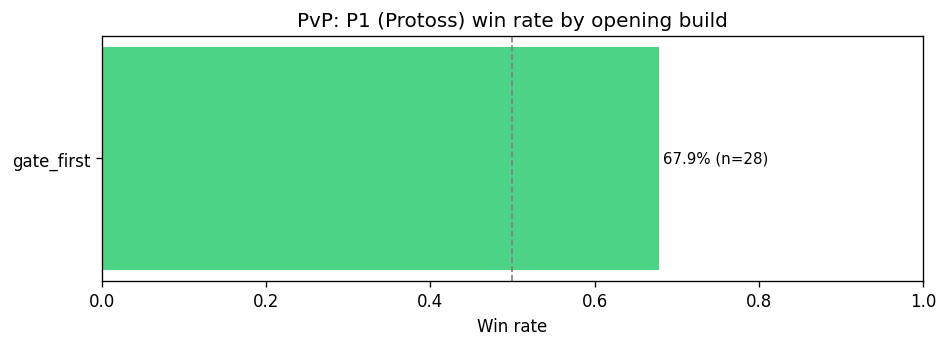


PvP — P2 (Protoss) opening win rates
─────────────────────────────────────────────
  cannon_rush         : 50.0%  (n=10)
  forge_first         : 45.5%  (n=11)
  gate_first          : 27.3%  (n=22)


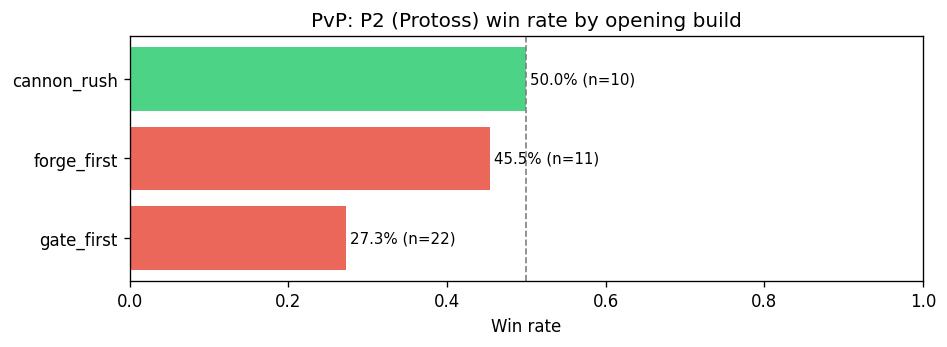

In [27]:
def opening_winrates(matchup, p_col='p1', race_label='P1'):
    """
    Show win rates by opening build for one player in a matchup.
    Groups by the first non-supply building that player placed.
    """
    df_m = df[df['matchup'] == matchup].copy()

    opening_cols = [c for c in df_m.columns if c.startswith(f'{p_col}_opening_')]
    if not opening_cols:
        print(f"No opening columns found for {p_col} in {matchup}.")
        print("Re-parse replays with updated parser.py first.")
        return

    # One row per game (opening is same across all checkpoints)
    games = df_m.groupby('replay_file').first().reset_index()

    # Win flag for this player
    pid = 1 if p_col == 'p1' else 2
    games['player_wins'] = (games['winner'] == pid).astype(int)

    print(f"\n{matchup} — {race_label} opening win rates\n{'─'*45}")

    results = []
    for col in sorted(opening_cols):
        opening_name = col.replace(f'{p_col}_opening_', '')
        subset = games[games[col] == 1]
        if len(subset) < 10:
            continue
        wr = subset['player_wins'].mean()
        results.append({'opening': opening_name, 'win_rate': wr, 'n': len(subset)})
        print(f"  {opening_name:20s}: {wr:.1%}  (n={len(subset)})")

    if not results:
        print("  No openings with enough games (n≥10).")
        return

    # Bar chart
    res_df = pd.DataFrame(results).sort_values('win_rate', ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, len(res_df) * 0.6)))
    colors = ['#2ecc71' if w >= 0.5 else '#e74c3c' for w in res_df['win_rate']]
    bars = ax.barh(res_df['opening'], res_df['win_rate'], color=colors, alpha=0.85)
    for bar, (_, row) in zip(bars, res_df.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{row['win_rate']:.1%} (n={int(row['n'])})",
                va='center', fontsize=9)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Win rate')
    ax.set_title(f'{matchup}: {race_label} win rate by opening build')
    plt.tight_layout()
    plt.show()


# PvP — both players are Protoss, so check both sides
opening_winrates('PvP', p_col='p1', race_label='P1 (Protoss)')
opening_winrates('PvP', p_col='p2', race_label='P2 (Protoss)')

In [28]:
# Head-to-head: specific opening matchups in PvP
df_pvp_games = df[df['matchup'] == 'PvP'].groupby('replay_file').first().reset_index()

h2h_pairs = [
    ('forge_first', 'gate_first',  'Forge vs Gate'),
    ('forge_first', 'nexus_first', 'Forge vs Nexus'),
    ('gate_first',  'nexus_first', 'Gate vs Nexus'),
    ('ffe',         'gate_first',  'FFE vs Gate'),
]

print("PvP head-to-head opening win rates (P1 opening vs P2 opening)\n")
for p1_open, p2_open, label in h2h_pairs:
    p1_col = f'p1_opening_{p1_open}'
    p2_col = f'p2_opening_{p2_open}'
    if p1_col not in df_pvp_games.columns or p2_col not in df_pvp_games.columns:
        print(f"  {label}: columns not found (re-parse first)")
        continue
    h2h = df_pvp_games[(df_pvp_games[p1_col] == 1) & (df_pvp_games[p2_col] == 1)]
    if len(h2h) < 5:
        print(f"  {label}: too few games (n={len(h2h)})")
        continue
    p1_wr = (h2h['winner'] == 1).mean()
    print(f"  {label:25s}: P1 wins {p1_wr:.1%}  (n={len(h2h)})")

PvP head-to-head opening win rates (P1 opening vs P2 opening)

  Forge vs Gate: too few games (n=4)
  Forge vs Nexus: too few games (n=0)
  Gate vs Nexus: too few games (n=0)
  FFE vs Gate: too few games (n=0)


In [29]:
# PvP — 1-gate expand analysis
df_pvp_games = df[df["matchup"] == "PvP"].groupby("replay_file").first().reset_index()

col_p1 = "p1_opening_1gate_expand"
col_p2 = "p2_opening_1gate_expand"

if col_p1 not in df_pvp_games.columns:
    print("1-gate expand columns not found — re-parse replays first.")
else:
    for p_col, pid, label in [("p1", 1, "P1"), ("p2", 2, "P2")]:
        col = f"{p_col}_opening_1gate_expand"
        subset = df_pvp_games[df_pvp_games[col] == 1]
        if len(subset) > 0:
            wr = (subset["winner"] == pid).mean()
            print(f"{label} 1-gate expand: {wr:.1%} win rate  (n={len(subset)})")

    print()

    p1_expand = df_pvp_games["p1_opening_1gate_expand"] == 1
    p2_expand = df_pvp_games["p2_opening_1gate_expand"] == 1

    h2h = df_pvp_games[p1_expand & ~p2_expand]
    if len(h2h) >= 5:
        wr = (h2h["winner"] == 1).mean()
        print(f"Expander vs non-expander: expander wins {wr:.1%}  (n={len(h2h)})")

    both = df_pvp_games[p1_expand & p2_expand]
    if len(both) >= 5:
        wr = (both["winner"] == 1).mean()
        print(f"Both 1-gate expand: P1 wins {wr:.1%}  (n={len(both)})")

    neither = df_pvp_games[~p1_expand & ~p2_expand]
    if len(neither) >= 5:
        wr = (neither["winner"] == 1).mean()
        print(f"Neither expands (aggressive mirror): P1 wins {wr:.1%}  (n={len(neither)})")


P1 1-gate expand: 77.8% win rate  (n=9)
P2 1-gate expand: 0.0% win rate  (n=3)

Expander vs non-expander: expander wins 75.0%  (n=8)
Neither expands (aggressive mirror): P1 wins 53.8%  (n=455)


In [30]:
game_lengths = df.groupby('replay_file')['game_length_s'].first()
print(f"Total games: {len(game_lengths)}")
print(f"Games > 15 min: {(game_lengths > 900).sum()} ({(game_lengths > 900).mean():.1%})")
print(f"Games > 20 min: {(game_lengths > 1200).sum()} ({(game_lengths > 1200).mean():.1%})")
print(f"Games > 25 min: {(game_lengths > 1500).sum()} ({(game_lengths > 1500).mean():.1%})")
print(f"\nMedian game length: {game_lengths.median()/60:.1f} min")
print(f"Max game length:    {game_lengths.max()/60:.1f} min")

Total games: 7018
Games > 15 min: 1105 (15.7%)
Games > 20 min: 378 (5.4%)
Games > 25 min: 138 (2.0%)

Median game length: 9.9 min
Max game length:    390.1 min
